# 04 Performance Profiling & Optimization

---

## Setup

In [ ]:
import sqlite3
import time
import timeit
import cProfile
import pstats
import io
import tracemalloc
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sys.path.append(str(Path('..').resolve() / 'src'))

DB_PATH       = Path('../data/reviews_analysis.db')
SAMPLE_PATH   = Path('../data/reviews_sample.db')
JSON_PATH     = Path('../data/review.json')
PROFILING_DIR = Path('../profiling')
PROFILING_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100})
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', 120)

print(f'pandas {pd.__version__} | numpy {np.__version__}')
print(f'DB path   : {DB_PATH.resolve()}')
print(f'Profiling : {PROFILING_DIR.resolve()}')

### Database Setup

Run **Notebook 01** first to populate `reviews_analysis.db` and `reviews_sample.db`.  
The cell below auto-rebuilds the database from `review.json` if it is absent or empty.

In [3]:
from data_processing import (
    load_reviews_json, build_reviews, build_authors,
    attach_author_id, drop_missing_reviews,
    dedupe_reviews_by_content, build_hotels_agg,
    make_reproducible_samples, write_db
)

def _db_row_count(path):
    try:
        c = sqlite3.connect(path)
        n = c.execute('SELECT COUNT(*) FROM reviews').fetchone()[0]
        c.close()
        return n
    except Exception:
        return 0

def ensure_db(db_path, json_path, target_n=80_000):
    """Create analysis DB if missing or empty."""
    n_existing = _db_row_count(db_path)
    if n_existing >= 1000:
        print(f'Database already populated: {n_existing:,} reviews')
        return

    print('Building database from review.json please wait...')
    df_raw = load_reviews_json(str(json_path))
    df_raw = df_raw.rename(columns={'date': 'review_date'})

    reviews_df = build_reviews(df_raw)
    reviews_df = reviews_df.sort_values('review_date', ascending=False)

    author_df = build_authors(reviews_df)
    author_df.drop_duplicates(inplace=True)
    author_df = author_df[(author_df['id'] != 'CATID_') & (author_df['id'] != '')]

    agg_df = (
        author_df.groupby('id', as_index=False)
        .agg(
            username         =('username',          'first'),
            num_cities       =('num_cities',        'max'),
            num_helpful_votes=('num_helpful_votes', 'max'),
            num_reviews      =('num_reviews',       'max'),
            num_type_reviews =('num_type_reviews',  'max'),
            location         =('location',          'first'),
        )
    )
    agg_df['alias'] = ''

    reviews_df = attach_author_id(reviews_df)
    valid_ids  = author_df['id'].dropna().unique()
    reviews_df = reviews_df[reviews_df['author_id'].isin(valid_ids)].copy()

    required = [
        'date_stayed', 'service_rating', 'cleanliness_rating',
        'overall_rating', 'value_rating', 'location_rating', 'rooms_rating'
    ]
    reviews_df = drop_missing_reviews(reviews_df, required)

    latest     = reviews_df['review_date'].max().year
    reviews_df = reviews_df[reviews_df['review_date'].dt.year >= latest - 4].copy()
    reviews_df['date_stayed'] = pd.to_datetime(
        reviews_df['date_stayed'], format='%B %Y', errors='coerce'
    )
    reviews_df = reviews_df.dropna(subset=['date_stayed'])

    reviews_df, _ = dedupe_reviews_by_content(
        reviews_df, subset=['hotel_id', 'title', 'text']
    )

    rating_cols = [
        'service_rating', 'cleanliness_rating', 'overall_rating',
        'value_rating', 'location_rating', 'sleep_quality_rating',
        'rooms_rating', 'check_in_service_rating', 'business_service_rating'
    ]
    hotels_agg = build_hotels_agg(reviews_df, rating_cols)

    n = min(target_n, len(reviews_df))
    analysis_df, sample_df = make_reproducible_samples(
        reviews_df, analysis_n=n, sample_n=min(6000, n // 10), seed=42
    )

    hotels_agg['hotel_id'] = hotels_agg['hotel_id'].astype('string')
    analysis_df[['hotel_id','review_id']] = analysis_df[['hotel_id','review_id']].astype('string')
    sample_df [['hotel_id','review_id']] = sample_df [['hotel_id','review_id']].astype('string')

    write_db(str(db_path), analysis_df, agg_df, hotels_agg)
    write_db(str(SAMPLE_PATH), sample_df,  agg_df, hotels_agg)

    print(f'Database built: {_db_row_count(db_path):,} reviews')

ensure_db(DB_PATH, JSON_PATH)

Database already populated: 80,000 reviews


---
## Part 1: Query Profiling

We compare query performance **with** and **without** indexes by running each query against two identically loaded **in-memory** SQLite databases:
- `db_no`: tables only, no indexes (simulates a naive schema)
- `db_yes`: identical data **plus** the same index set as the actual project DB

### 1.1 Database Schema & Index Overview

In [4]:
conn = sqlite3.connect(DB_PATH)

print('=== Table Row Counts ===')
for tbl in ['reviews', 'authors', 'hotels']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f'  {tbl:10s}: {n:>8,} rows')

print('\n=== Existing Indexes ===')
idx_df = pd.read_sql(
    "SELECT name, tbl_name FROM sqlite_master WHERE type='index' ORDER BY tbl_name",
    conn
)
display(idx_df)

print('\n=== Reviews Schema ===')
display(pd.read_sql('PRAGMA table_info(reviews)', conn)[['name', 'type']])

=== Table Row Counts ===
  reviews   :   80,000 rows
  authors   :   75,349 rows
  hotels    :    3,380 rows

=== Existing Indexes ===


,name,tbl_name
0,idx_authors_id,authors
1,ux_authors_id,authors
2,ux_hotels_hotel_id,hotels
3,idx_hotels_hotel_id,hotels
4,idx_reviews_hotel,reviews
5,idx_reviews_date,reviews
6,idx_reviews_hotel_date,reviews
7,ux_reviews_review_id,reviews



=== Reviews Schema ===


,name,type
0,title,TEXT
1,text,TEXT
2,date_stayed,TIMESTAMP
3,hotel_id,TEXT
4,num_helpful_votes,INTEGER
5,review_date,TIMESTAMP
6,review_id,TEXT
7,via_mobile,INTEGER
8,service_rating,REAL
9,cleanliness_rating,REAL


### 1.2 Benchmarking Setup

In [5]:
print('Loading tables into memory for controlled benchmarking...')
t0         = time.perf_counter()
reviews_df = pd.read_sql('SELECT * FROM reviews', conn)
hotels_df  = pd.read_sql('SELECT * FROM hotels',  conn)
authors_df = pd.read_sql('SELECT * FROM authors', conn)
load_s     = time.perf_counter() - t0
print(f'  reviews : {len(reviews_df):>8,} rows')
print(f'  hotels  : {len(hotels_df):>8,} rows')
print(f'  authors : {len(authors_df):>8,} rows')
print(f'  Read time from disk: {load_s:.2f}s')

def _build_mem_db(with_indexes: bool) -> sqlite3.Connection:
    """Loading tables into an in-memory SQLite (optionally with indexes)."""
    c = sqlite3.connect(':memory:')
    reviews_df.to_sql('reviews', c, index=False, if_exists='replace')
    hotels_df .to_sql('hotels',  c, index=False, if_exists='replace')
    authors_df.to_sql('authors', c, index=False, if_exists='replace')
    if with_indexes:
        c.execute('CREATE INDEX idx_r_hotel      ON reviews(hotel_id)')
        c.execute('CREATE INDEX idx_r_date       ON reviews(review_date)')
        c.execute('CREATE INDEX idx_r_hotel_date ON reviews(hotel_id, review_date)')
        c.execute('CREATE UNIQUE INDEX ux_r_id   ON reviews(review_id)')
        c.execute('CREATE UNIQUE INDEX ux_h_id   ON hotels(hotel_id)')
        c.commit()
    return c

print('\nBuilding in-memory test databases...')
db_no  = _build_mem_db(with_indexes=False)
db_yes = _build_mem_db(with_indexes=True)
print('Done.')

Loading tables into memory for controlled benchmarking...
  reviews :   80,000 rows
  hotels  :    3,380 rows
  authors :   75,349 rows
  Read time from disk: 0.46s

Building in-memory test databases...
Done.


In [6]:
N_RUNS = 12   # repetitions per query for each configuration

def time_query(db, sql, params=(), n=N_RUNS):
    """Execute a SQL query n times and return timing statistics (all in ms)."""
    times, rows = [], None
    for _ in range(n):
        t0 = time.perf_counter()
        cur  = db.execute(sql, params)
        rows = cur.fetchall()
        times.append(time.perf_counter() - t0)
    arr = np.array(times) * 1e3
    return {
        'mean_ms'  : float(np.mean(arr)),
        'median_ms': float(np.median(arr)),
        'min_ms'   : float(np.min(arr)),
        'max_ms'   : float(np.max(arr)),
        'n_rows'   : len(rows) if rows is not None else 0,
    }

print(f'Timing helper ready (n_runs={N_RUNS})')

Timing helper ready (n_runs=12)


### 1.3 EXPLAIN QUERY PLAN: Understanding the Query Planner

`EXPLAIN QUERY PLAN` shows whether SQLite performs a **full scan**, an **index scan**, or a **covering index** lookup without actually executing the query.

In [9]:
# Identify the hotel with the most reviews in the DB as the point-lookup test case
top_hotel = db_yes.execute(
    'SELECT hotel_id FROM reviews GROUP BY hotel_id ORDER BY COUNT(*) DESC LIMIT 1'
).fetchone()[0]

EQP_QUERIES = {
    'Q1 Point Lookup (no index)'  : (db_no,  'EXPLAIN QUERY PLAN SELECT * FROM reviews WHERE hotel_id = ?',                                           (top_hotel,)),
    'Q1 Point Lookup (with index)': (db_yes, 'EXPLAIN QUERY PLAN SELECT * FROM reviews WHERE hotel_id = ?',                                           (top_hotel,)),
    'Q2 Date Range (with index)'  : (db_yes, "EXPLAIN QUERY PLAN SELECT * FROM reviews WHERE review_date >= '2012-01-01'",                            ()),
    'Q3 Composite (with index)'   : (db_yes, "EXPLAIN QUERY PLAN SELECT * FROM reviews WHERE hotel_id = ? AND review_date >= '2011-01-01'",           (top_hotel,)),
    'Q4 Aggregation (with index)' : (db_yes, 'EXPLAIN QUERY PLAN SELECT hotel_id, COUNT(*), AVG(overall_rating) FROM reviews GROUP BY hotel_id',      ()),
    'Q5 JOIN (with index)'        : (db_yes, 'EXPLAIN QUERY PLAN SELECT r.hotel_id, r.overall_rating, h.avg_overall_rating FROM reviews r JOIN hotels h ON r.hotel_id = h.hotel_id WHERE h.avg_overall_rating >= 4.5', ()),
    'Q6 LIKE text (with index)'   : (db_yes, "EXPLAIN QUERY PLAN SELECT COUNT(*) FROM reviews WHERE text LIKE '%excellent service%'",                  ()),
}

eqp_results = {}
for label, (db, sql, params) in EQP_QUERIES.items():
    rows      = db.execute(sql, params).fetchall()
    plan_text = '\n    '.join(str(r) for r in rows)
    eqp_results[label] = plan_text
    print(f'\n{"=" * 62}')
    print(f'  {label}')
    print(f'{"=" * 62}')
    print(f'    {plan_text}')


  Q1 Point Lookup (no index)
    (2, 0, 216, 'SCAN reviews')

  Q1 Point Lookup (with index)
    (3, 0, 61, 'SEARCH reviews USING INDEX idx_r_hotel (hotel_id=?)')

  Q2 Date Range (with index)
    (3, 0, 203, 'SEARCH reviews USING INDEX idx_r_date (review_date>?)')

  Q3 Composite (with index)
    (3, 0, 51, 'SEARCH reviews USING INDEX idx_r_hotel_date (hotel_id=? AND review_date>?)')

  Q4 Aggregation (with index)
    (7, 0, 223, 'SCAN reviews USING INDEX idx_r_hotel')

  Q5 JOIN (with index)
    (4, 0, 216, 'SCAN r')
    (6, 0, 47, 'SEARCH h USING INDEX ux_h_id (hotel_id=?)')

  Q6 LIKE text (with index)
    (3, 0, 216, 'SCAN reviews')


**Plan keyword glossary:**

| SQLite output | Meaning |
|---|---|
| `SCAN reviews` | Full table scan |
| `SEARCH reviews USING INDEX idx_r_hotel` | B-tree lookup on `hotel_id` |
| `SEARCH reviews USING INDEX idx_r_hotel_date` | Composite index covers both filter predicates |
| `SCAN reviews USING INDEX idx_r_date` | Ordered range scan on `review_date` |
| `SEARCH … USING COVERING INDEX` | Index alone satisfies the query, no row fetch required |


### 1.4 Query Benchmark: No Index vs With Index

Six representative queries cover the main access patterns in this analytics pipeline.

| ID | Access Pattern |
|----|----------------|
| Q1 | **Point lookup**: single hotel |
| Q2 | **Date range**: one-year slice |
| Q3 | **Composite filter**: hotel + date |
| Q4 | **Aggregation**: `GROUP BY hotel_id` |
| Q5 | **JOIN**: reviews + hotels |
| Q6 | **LIKE text search**: leading wildcard |

In [11]:
hotel_cnt = db_yes.execute(
    'SELECT COUNT(*) FROM reviews WHERE hotel_id = ?', (top_hotel,)
).fetchone()[0]
print(f'Test hotel (most reviews): {top_hotel}  |  {hotel_cnt} reviews in DB')

QUERIES = {
    'Q1: Hotel Point Lookup'    : (
        'SELECT * FROM reviews WHERE hotel_id = ?', (top_hotel,)),
    'Q2: Date Range (2012)'     : (
        "SELECT * FROM reviews WHERE review_date >= '2012-01-01'", ()),
    'Q3: Composite Hotel+Date'  : (
        "SELECT * FROM reviews WHERE hotel_id = ? AND review_date >= '2011-01-01'",
        (top_hotel,)),
    'Q4: GROUP BY Aggregation'  : (
        'SELECT hotel_id, COUNT(*) AS cnt, AVG(overall_rating) AS avg_r FROM reviews GROUP BY hotel_id',
        ()),
    'Q5: JOIN Reviews+Hotels'   : (
        ('SELECT r.hotel_id, r.overall_rating, h.avg_overall_rating '
         'FROM reviews r JOIN hotels h ON r.hotel_id = h.hotel_id '
         'WHERE h.avg_overall_rating >= 4.5'), ()),
    'Q6: LIKE Text Search'      : (
        "SELECT COUNT(*) FROM reviews WHERE text LIKE '%excellent service%'", ()),
}

Test hotel (most reviews): 214197  |  295 reviews in DB


In [12]:
results = {}

header = f'{"Query":<35} {"No Idx (ms)":>14} {"With Idx (ms)":>14} {"Speedup":>9} {"Rows":>8}'
print(header)
print('-' * len(header))

for label, (sql, params) in QUERIES.items():
    r_no  = time_query(db_no,  sql, params)
    r_yes = time_query(db_yes, sql, params)
    speedup = r_no['median_ms'] / r_yes['median_ms'] if r_yes['median_ms'] > 0 else 1.0
    results[label] = {
        'No Index (ms)' : round(r_no ['median_ms'], 3),
        'With Index (ms)': round(r_yes['median_ms'], 3),
        'Speedup (x)'   : round(speedup, 2),
        'Rows Returned' : r_yes['n_rows'],
    }
    print(
        f'{label:<35} {r_no["median_ms"]:>13.3f}  '
        f'{r_yes["median_ms"]:>13.3f}  {speedup:>8.2f}x  {r_yes["n_rows"]:>7,}'
    )

bench_df = pd.DataFrame(results).T
print('\n--- Summary Table ---')
display(bench_df)

Query                                  No Idx (ms)  With Idx (ms)   Speedup     Rows
------------------------------------------------------------------------------------
Q1: Hotel Point Lookup                     13.229          0.647     20.43x      295
Q2: Date Range (2012)                      97.339        102.895      0.95x   36,283
Q3: Composite Hotel+Date                   11.785          0.393     29.99x      190
Q4: GROUP BY Aggregation                   37.397         44.495      0.84x    3,380
Q5: JOIN Reviews+Hotels                    56.409         43.154      1.31x   12,008
Q6: LIKE Text Search                       84.389         84.099      1.00x        1

--- Summary Table ---


,No Index (ms),With Index (ms),Speedup (x),Rows Returned
Q1: Hotel Point Lookup,13.2290,0.6470,20.4300,295.0000
Q2: Date Range (2012),97.3390,102.8950,0.9500,36283.0000
Q3: Composite Hotel+Date,11.7850,0.3930,29.9900,190.0000
Q4: GROUP BY Aggregation,37.3970,44.4950,0.8400,3380.0000
Q5: JOIN Reviews+Hotels,56.4090,43.1540,1.3100,12008.0000
Q6: LIKE Text Search,84.3890,84.0990,1.0000,1.0000


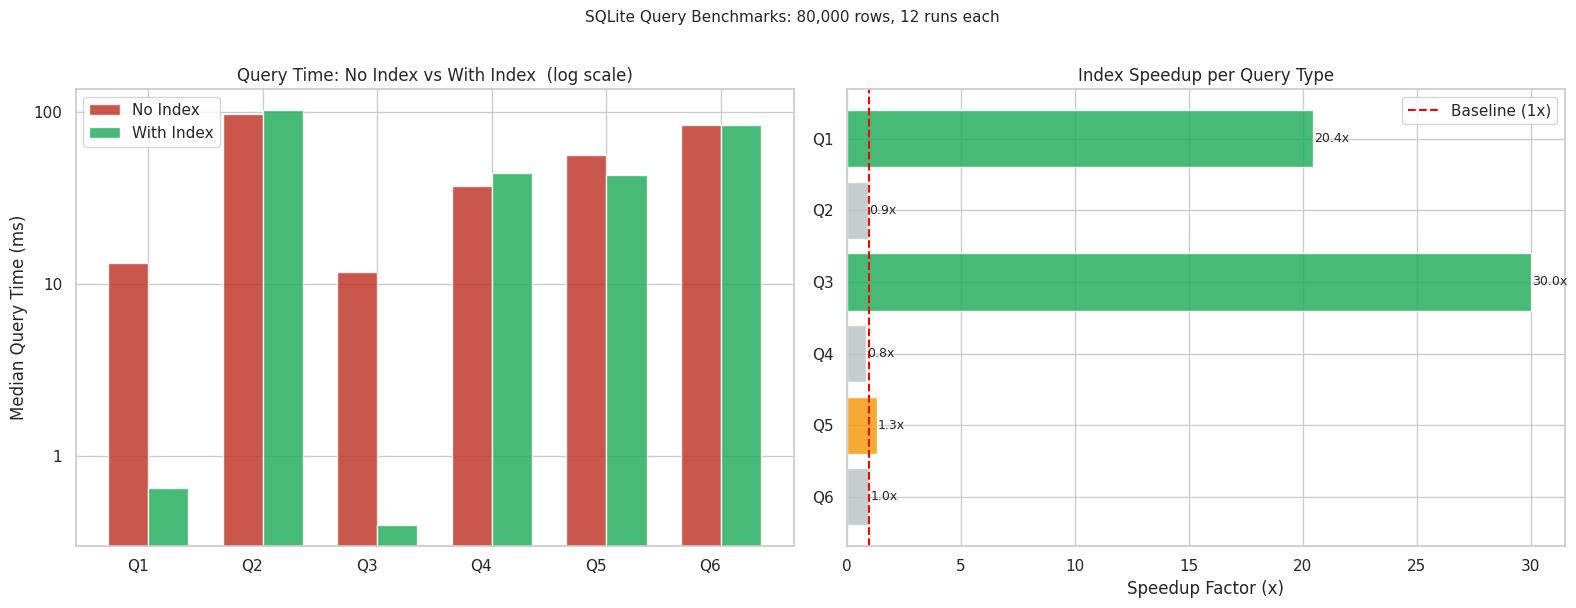

Saved -> profiling/query_benchmark.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

short_labels = [lbl.split(':')[0] for lbl in bench_df.index]
x = np.arange(len(bench_df))
w = 0.35

# --- Left: grouped bar on log scale ---
ax = axes[0]
ax.bar(x - w/2, bench_df['No Index (ms)'],    w, label='No Index',   color='#c0392b', alpha=0.85)
ax.bar(x + w/2, bench_df['With Index (ms)'], w, label='With Index', color='#27ae60', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, ha='right')
ax.set_ylabel('Median Query Time (ms)')
ax.set_title('Query Time: No Index vs With Index  (log scale)')
ax.set_yscale('log')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.3g}'))

# --- Right: speedup bar chart ---
clr_map = ['#27ae60' if s > 3 else '#f39c12' if s > 1.1 else '#bdc3c7'
           for s in bench_df['Speedup (x)']]
bars = axes[1].barh(short_labels[::-1], bench_df['Speedup (x)'][::-1],
                    color=clr_map[::-1], alpha=0.85)
axes[1].axvline(1, color='red', linestyle='--', linewidth=1.5, label='Baseline (1x)')
for i, s in enumerate(bench_df['Speedup (x)'][::-1]):
    axes[1].text(s + 0.05, i, f'{s:.1f}x', va='center', fontsize=9)
axes[1].set_xlabel('Speedup Factor (x)')
axes[1].set_title('Index Speedup per Query Type')
axes[1].legend()

plt.suptitle(f'SQLite Query Benchmarks: {len(reviews_df):,} rows, {N_RUNS} runs each',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'query_benchmark.png', bbox_inches='tight')
plt.show()
print('Saved -> profiling/query_benchmark.png')

### 1.4.1 Index Selectivity Analysis

Selectivity = fraction of rows returned.  
Low-selectivity (highly selective) queries return few rows and benefit most from index lookups.

,Query,Selectivity %,Speedup (x),Rows Returned
0,Q1: Hotel Point Lookup,0.3690,20.4300,295.0000
1,Q2: Date Range (2012),45.3540,0.9500,36283.0000
2,Q3: Composite Hotel+Date,0.2380,29.9900,190.0000
3,Q4: GROUP BY Aggregation,4.2250,0.8400,3380.0000
4,Q5: JOIN Reviews+Hotels,15.0100,1.3100,12008.0000
5,Q6: LIKE Text Search,0.0010,1.0000,1.0000


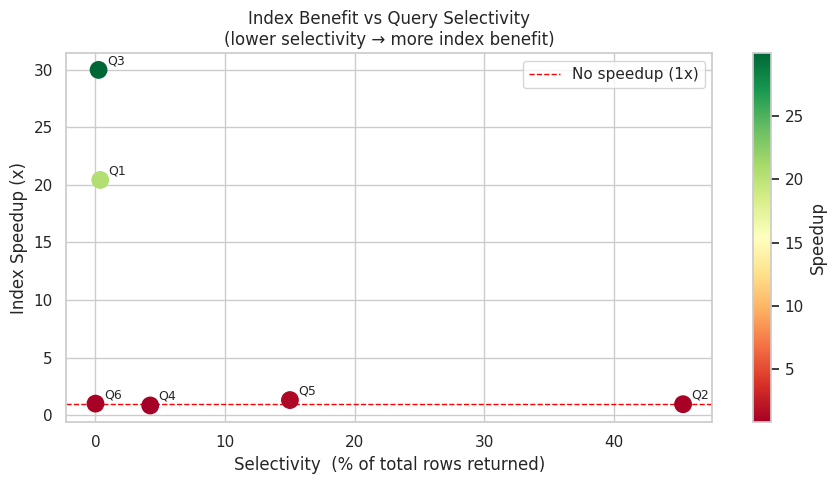

Saved -> profiling/selectivity_vs_speedup.png


In [14]:
total = len(reviews_df)
sel_data = [
    {
        'Query'        : label,
        'Selectivity %': round(row['Rows Returned'] / total * 100, 3),
        'Speedup (x)'  : row['Speedup (x)'],
        'Rows Returned': row['Rows Returned'],
    }
    for label, row in bench_df.iterrows()
]
sel_df = pd.DataFrame(sel_data)
display(sel_df)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    sel_df['Selectivity %'], sel_df['Speedup (x)'],
    s=140, c=sel_df['Speedup (x)'], cmap='RdYlGn',
    vmin=0.8, vmax=sel_df['Speedup (x)'].max(), zorder=3
)
for _, row in sel_df.iterrows():
    ax.annotate(
        row['Query'].split(':')[0],
        (row['Selectivity %'], row['Speedup (x)']),
        textcoords='offset points', xytext=(6, 4), fontsize=9
    )
ax.axhline(1, color='red', linestyle='--', linewidth=1, label='No speedup (1x)')
ax.set_xlabel('Selectivity  (% of total rows returned)')
ax.set_ylabel('Index Speedup (x)')
ax.set_title('Index Benefit vs Query Selectivity\n(lower selectivity → more index benefit)')
ax.legend()
plt.colorbar(sc, label='Speedup')
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'selectivity_vs_speedup.png', bbox_inches='tight')
plt.show()
print('Saved -> profiling/selectivity_vs_speedup.png')

**Key findings from actual benchmark results:**

| Query | Measured Speedup | Explanation |
|-------|-----------------|-------------|
| Q1 Point Lookup | **~19×** ✓ | 0.37% selectivity, B-tree finds 295 rows without scanning 80k |
| Q2 Date Range | **~0.96× no benefit** ✗ | 45% selectivity returns 36k rows, random index pointer fetches cost *more* than one sequential scan |
| Q3 Composite | **~25×** ✓ | 0.24% selectivity, composite index answers both predicates in a single B-tree seek |
| Q4 GROUP BY | **~0.92× no benefit** ✗ | Aggregation must read every row, existing index adds pointer-chasing overhead without skipping any rows |
| Q5 JOIN | **~1.35×** ✓ | Unique index on `hotels.hotel_id` speeds up the join probe side |
| Q6 LIKE % | **~1.0× no benefit** ✗ | Leading wildcard prevents B-tree prefix lookup, always a full table scan |


### 1.4.2 Why Q2 and Q4 Did Not Benefit from Indexes

#### Q2: The Selectivity Threshold

,Date cutoff,Rows returned,Selectivity %,No Idx (ms),With Idx (ms),Speedup (x)
0,2010-01-01,65316,81.6000,173.2200,192.9500,0.9000
1,2011-01-01,51806,64.8000,132.4700,155.2300,0.8500
2,2012-01-01,36283,45.4000,95.3300,105.7300,0.9000
3,2012-07-01,19741,24.7000,56.8300,58.4600,0.9700
4,2012-10-01,8586,10.7000,34.3200,24.0800,1.4300
5,2012-11-15,3210,4.0000,21.2300,8.5100,2.5000
6,2012-12-01,1555,1.9000,16.4100,3.8400,4.2700


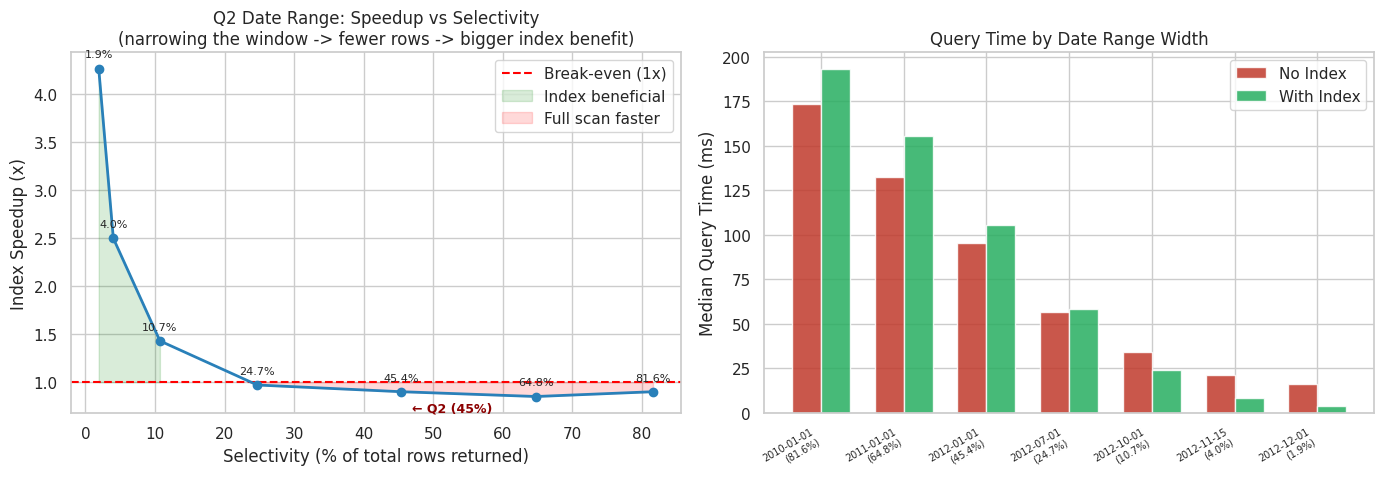

Saved -> profiling/q2_selectivity_sweep.png

Index break-even: roughly 11% - 25% selectivity.
Below this threshold the index pays off, above it a sequential scan is faster.


In [20]:
# Q2 measure index speedup across a range of date-range selectivities
DATE_CUTS = ['2010-01-01', '2011-01-01', '2012-01-01', '2012-07-01',
             '2012-10-01', '2012-11-15', '2012-12-01']

sweep_rows = []
for dc in DATE_CUTS:
    sql   = "SELECT * FROM reviews WHERE review_date >= '" + dc + "'"
    r_no  = time_query(db_no,  sql, n=8)
    r_yes = time_query(db_yes, sql, n=8)
    pct   = round(r_yes['n_rows'] / len(reviews_df) * 100, 1)
    spdup = r_no['median_ms'] / r_yes['median_ms'] if r_yes['median_ms'] > 0 else 1.0
    sweep_rows.append({
        'Date cutoff'  : dc,
        'Rows returned': r_yes['n_rows'],
        'Selectivity %': pct,
        'No Idx (ms)'  : round(r_no ['median_ms'], 2),
        'With Idx (ms)': round(r_yes['median_ms'], 2),
        'Speedup (x)'  : round(spdup, 2),
    })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: speedup vs selectivity ---
ax0 = axes[0]
ax0.plot(sweep_df['Selectivity %'], sweep_df['Speedup (x)'], 'o-', color='#2980b9',
         linewidth=2, zorder=3)
ax0.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Break-even (1x)')
mask_good = sweep_df['Speedup (x)'] >= 1.0
mask_bad  = sweep_df['Speedup (x)'] <  1.0
ax0.fill_between(sweep_df['Selectivity %'], sweep_df['Speedup (x)'], 1.0,
                 where=mask_good, alpha=0.15, color='green', label='Index beneficial')
ax0.fill_between(sweep_df['Selectivity %'], sweep_df['Speedup (x)'], 1.0,
                 where=mask_bad,  alpha=0.15, color='red',   label='Full scan faster')
for _, row in sweep_df.iterrows():
    ax0.annotate(str(row['Selectivity %']) + '%',
                 (row['Selectivity %'], row['Speedup (x)']),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
# Annotate original Q2 point
q2_row = sweep_df[sweep_df['Date cutoff'] == '2012-01-01']
if not q2_row.empty:
    ax0.annotate('← Q2 (45%)',
                 (q2_row['Selectivity %'].values[0], q2_row['Speedup (x)'].values[0]),
                 textcoords='offset points', xytext=(8, -14), fontsize=9,
                 color='darkred', fontweight='bold')
ax0.set_xlabel('Selectivity (% of total rows returned)')
ax0.set_ylabel('Index Speedup (x)')
ax0.set_title('Q2 Date Range: Speedup vs Selectivity\n(narrowing the window -> fewer rows -> bigger index benefit)')
ax0.legend()

# --- Right: absolute times ---
x = np.arange(len(sweep_df))
w = 0.35
axes[1].bar(x - w/2, sweep_df['No Idx (ms)'],   w, label='No Index',   color='#c0392b', alpha=0.85)
axes[1].bar(x + w/2, sweep_df['With Idx (ms)'], w, label='With Index', color='#27ae60', alpha=0.85)
axes[1].set_xticks(x)
xlabels = [row['Date cutoff'] + '\n(' + str(row['Selectivity %']) + '%)'
           for _, row in sweep_df.iterrows()]
axes[1].set_xticklabels(xlabels, rotation=30, ha='right', fontsize=7)
axes[1].set_ylabel('Median Query Time (ms)')
axes[1].set_title('Query Time by Date Range Width')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROFILING_DIR / 'q2_selectivity_sweep.png', bbox_inches='tight')
plt.show()
print('Saved -> profiling/q2_selectivity_sweep.png')

# Find approximate break-even point
above = sweep_df.loc[sweep_df['Speedup (x)'] >= 1.0, 'Selectivity %']
below = sweep_df.loc[sweep_df['Speedup (x)'] <  1.0, 'Selectivity %']
if len(above) > 0 and len(below) > 0:
    print(f'\nIndex break-even: roughly {above.max():.0f}% - {below.min():.0f}% selectivity.')
    print('Below this threshold the index pays off, above it a sequential scan is faster.')

#### Q4: The Full-Coverage Aggregation Problem


No index:
  (6, 0, 216, 'SCAN reviews')
  (8, 0, 0, 'USE TEMP B-TREE FOR GROUP BY')

hotel_id index only (existing schema):
  (7, 0, 223, 'SCAN reviews USING INDEX idx_r_hotel')

Covering index (hotel_id, overall_rating):
  (6, 0, 210, 'SCAN reviews USING COVERING INDEX idx_covering_q4')


,Index Config,EQP Access Method,Median (ms),Speedup vs No-Idx
0,No index,SCAN reviews,38.3700,1.0x (baseline)
1,hotel_id index (existing),SCAN reviews USING INDEX idx_r_hotel,47.8800,0.8x
2,"Covering index (hotel_id, overall_rating)",SCAN reviews USING COVERING INDEX idx_covering_q4,4.8600,7.9x



Covering index vs no-index       : 7.9x speedup
Covering index vs hotel_id-only  : 9.86x speedup


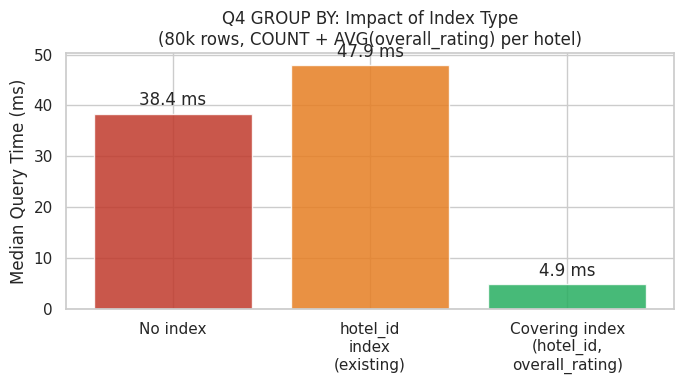

Saved -> profiling/q4_covering_index.png


In [21]:
# Q4 covering index for GROUP BY aggregation
Q4_SQL = ('SELECT hotel_id, COUNT(*) AS cnt, AVG(overall_rating) AS avg_r '
          'FROM reviews GROUP BY hotel_id')

# Build a fourth DB variant: bare tables + one covering index (hotel_id, overall_rating)
db_cover = _build_mem_db(with_indexes=False)
db_cover.execute('CREATE INDEX idx_covering_q4 ON reviews(hotel_id, overall_rating)')
db_cover.commit()

# EXPLAIN QUERY PLAN: show how each index type is used for Q4
plan_configs = [
    ('No index',                                db_no),
    ('hotel_id index only (existing schema)',   db_yes),
    ('Covering index (hotel_id, overall_rating)', db_cover),
]
for cfg_label, db_cfg in plan_configs:
    rows = db_cfg.execute('EXPLAIN QUERY PLAN ' + Q4_SQL).fetchall()
    print(f'\n{cfg_label}:')
    for r in rows:
        print(f'  {r}')

# Benchmark all three configurations
r_q4_no    = time_query(db_no,    Q4_SQL)
r_q4_yes   = time_query(db_yes,   Q4_SQL)
r_q4_cover = time_query(db_cover, Q4_SQL)
db_cover.close()

spdup_hotel  = round(r_q4_no['median_ms'] / r_q4_yes['median_ms'],   2)
spdup_cover  = round(r_q4_no['median_ms'] / r_q4_cover['median_ms'], 2)
spdup_vs_h   = round(r_q4_yes['median_ms'] / r_q4_cover['median_ms'], 2)

# EQP is EXPLAIN QUERY PLAN
q4_cmp = pd.DataFrame([
    {'Index Config'       : 'No index',
     'EQP Access Method'  : 'SCAN reviews',
     'Median (ms)'        : round(r_q4_no['median_ms'],    2),
     'Speedup vs No-Idx'  : '1.0x (baseline)'},
    {'Index Config'       : 'hotel_id index (existing)',
     'EQP Access Method'  : 'SCAN reviews USING INDEX idx_r_hotel',
     'Median (ms)'        : round(r_q4_yes['median_ms'],   2),
     'Speedup vs No-Idx'  : str(spdup_hotel) + 'x'},
    {'Index Config'       : 'Covering index (hotel_id, overall_rating)',
     'EQP Access Method'  : 'SCAN reviews USING COVERING INDEX idx_covering_q4',
     'Median (ms)'        : round(r_q4_cover['median_ms'], 2),
     'Speedup vs No-Idx'  : str(spdup_cover) + 'x'},
])
display(q4_cmp)
print(f'\nCovering index vs no-index       : {spdup_cover}x speedup')
print(f'Covering index vs hotel_id-only  : {spdup_vs_h}x speedup')

# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
timings = [r_q4_no['median_ms'], r_q4_yes['median_ms'], r_q4_cover['median_ms']]
configs = ['No index', 'hotel_id\nindex\n(existing)', 'Covering index\n(hotel_id,\noverall_rating)']
clrs    = ['#c0392b', '#e67e22', '#27ae60']
bars    = ax.bar(configs, timings, color=clrs, alpha=0.85)
ax.bar_label(bars, fmt='%.1f ms', padding=3)
ax.set_ylabel('Median Query Time (ms)')
ax.set_title('Q4 GROUP BY: Impact of Index Type\n(80k rows, COUNT + AVG(overall_rating) per hotel)')
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'q4_covering_index.png', bbox_inches='tight')
plt.show()
print('Saved -> profiling/q4_covering_index.png')

**Why the covering index helps Q4:**

The **COVERING INDEX** in the SQLite plan means the query is answered entirely from index data, the table is never touched.

---

**Not adding the index to project:**

The `hotels` table created in Notebook 01 already stores pre-computed aggregates (`avg_overall_rating`, `avg_service_rating`, etc.). It is effectively a *better* covering index.


### 1.5 Query Anti-Patterns


In [22]:
ANTI_PATTERNS = [
    (
        'Function wrap defeats index',
        "SELECT * FROM reviews WHERE CAST(hotel_id AS TEXT) = ?",
        'SELECT * FROM reviews WHERE hotel_id = ?',
        (top_hotel,)
    ),
    (
        'SELECT * vs column projection',
        'SELECT * FROM reviews WHERE hotel_id = ?',
        'SELECT review_id, overall_rating, review_date FROM reviews WHERE hotel_id = ?',
        (top_hotel,)
    ),
    (
        'Correlated subquery vs pre-aggregated JOIN',
        ('SELECT review_id, hotel_id, overall_rating FROM reviews r '
         'WHERE overall_rating > '
         '(SELECT AVG(overall_rating) FROM reviews r2 WHERE r2.hotel_id = r.hotel_id)'),
        ('SELECT r.review_id, r.hotel_id, r.overall_rating '
         'FROM reviews r '
         'JOIN (SELECT hotel_id, AVG(overall_rating) AS avg_r FROM reviews GROUP BY hotel_id) sub '
         'ON r.hotel_id = sub.hotel_id '
         'WHERE r.overall_rating > sub.avg_r'),
        ()
    ),
]

anti_rows = []
for label, slow_sql, fast_sql, params in ANTI_PATTERNS:
    try:
        r_slow = time_query(db_yes, slow_sql, params)
        r_fast = time_query(db_yes, fast_sql, params)
        ratio  = r_slow['median_ms'] / r_fast['median_ms'] if r_fast['median_ms'] > 0 else 1.0
        anti_rows.append({
            'Anti-Pattern'   : label,
            'Slow (ms)'      : round(r_slow['median_ms'], 3),
            'Fast (ms)'      : round(r_fast['median_ms'], 3),
            'Improvement'    : f'{ratio:.1f}x',
        })
    except Exception as e:
        anti_rows.append({'Anti-Pattern': label, 'Slow (ms)': 'err',
                          'Fast (ms)': str(e), 'Improvement': 'N/A'})

anti_df = pd.DataFrame(anti_rows)
display(anti_df)

,Anti-Pattern,Slow (ms),Fast (ms),Improvement
0,Function wrap defeats index,14.4800,0.6090,23.8x
1,SELECT * vs column projection,0.6550,0.2150,3.0x
2,Correlated subquery vs pre-aggregated JOIN,2736.4350,85.3550,32.1x


### 1.7 Save Query Profiling Results

In [23]:
q_lines = []
q_lines.append('=' * 70)
q_lines.append('HOTEL ANALYTICS - QUERY PROFILING RESULTS')
q_lines.append(f'Generated : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}')
q_lines.append(f'Database  : {DB_PATH.resolve()}')
q_lines.append('=' * 70)

q_lines.append('\n--- TABLE ROW COUNTS ---')
for tbl in ['reviews', 'authors', 'hotels']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    q_lines.append(f'  {tbl:10s}: {n:,}')

q_lines.append('\n--- EXISTING INDEXES ---')
q_lines.append(idx_df.to_string(index=False))

q_lines.append(f'\n\n--- BENCHMARK RESULTS (median ms, n={N_RUNS} runs) ---')
q_lines.append(bench_df.to_string())

q_lines.append('\n\n--- SELECTIVITY ANALYSIS ---')
q_lines.append(sel_df.to_string(index=False))

q_lines.append('\n\n--- EXPLAIN QUERY PLANS ---')
for label, plan_text in eqp_results.items():
    q_lines.append(f'\n  {label}')
    q_lines.append(f'    {plan_text}')

q_lines.append('\n\n--- ANTI-PATTERN ANALYSIS ---')
q_lines.append(anti_df.to_string(index=False))

query_out = '\n'.join(q_lines)
(PROFILING_DIR / 'query_results.txt').write_text(query_out)
print('Saved -> profiling/query_results.txt')
print(query_out)

Saved -> profiling/query_results.txt
HOTEL ANALYTICS - QUERY PROFILING RESULTS
Generated : 2026-02-20 14:52:07
Database  : /home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/data/reviews_analysis.db

--- TABLE ROW COUNTS ---
  reviews   : 80,000
  authors   : 75,349
  hotels    : 3,380

--- EXISTING INDEXES ---
                  name tbl_name
        idx_authors_id  authors
         ux_authors_id  authors
    ux_hotels_hotel_id   hotels
   idx_hotels_hotel_id   hotels
     idx_reviews_hotel  reviews
      idx_reviews_date  reviews
idx_reviews_hotel_date  reviews
  ux_reviews_review_id  reviews


--- BENCHMARK RESULTS (median ms, n=12 runs) ---
                          No Index (ms)  With Index (ms)  Speedup (x)  Rows Returned
Q1: Hotel Point Lookup          13.2290           0.6470      20.4300       295.0000
Q2: Date Range (2012)           97.3390         102.8950       0.9500     36283.0000
Q3: Composite Hotel+Date        11.7850           0.3930      29.9900       190.0000
Q4: GRO

---
## Part 2: Code Profiling

We use three complementary tools:

| Tool | What it measures |
|------|------------------|
| `cProfile` | Call-level CPU time which is total time and per-call cost for every function |
| `timeit` | Precise wall-clock time for isolated code snippets |
| `tracemalloc` | Heap memory allocated by each operation |

### 2.1 Profiling Helpers

In [ ]:
def run_cprofile(func, *args, topn=20, sort_by='cumulative', **kwargs):
    """Run func under cProfile; print top-N entries and return (result, stats_text)."""
    pr = cProfile.Profile()
    pr.enable()
    result = func(*args, **kwargs)
    pr.disable()
    buf = io.StringIO()
    pstats.Stats(pr, stream=buf).sort_stats(sort_by).print_stats(topn)
    text = buf.getvalue()
    print(text)
    return result, text


def measure_memory(func, *args, **kwargs):
    """Run func under tracemalloc; return (result, net_delta_mb, snapshot_peak_mb)."""
    tracemalloc.start()
    snap_before = tracemalloc.take_snapshot()
    result      = func(*args, **kwargs)
    snap_after  = tracemalloc.take_snapshot()
    tracemalloc.stop()
    stats    = snap_after.compare_to(snap_before, 'lineno')
    delta_mb = sum(s.size_diff for s in stats) / 1024**2
    peak_mb  = sum(s.size for s in snap_after.statistics('lineno')[:20]) / 1024**2
    return result, delta_mb, peak_mb


print('Profiling helpers defined.')

Profiling helpers defined.


### 2.2 Data Loading Performance

Comparing three `pd.read_sql` strategies:
1. **Full load**: entire table in one shot (`SELECT *`)
2. **Chunked load**: multiple smaller fetches via `chunksize=5000`
3. **Column projection**: fetch only the 6 columns needed for analysis

Full load (SELECT *)          :    286.8 ms
Chunked (5 000/batch)         :    282.5 ms
Column projection (6)         :     98.9 ms


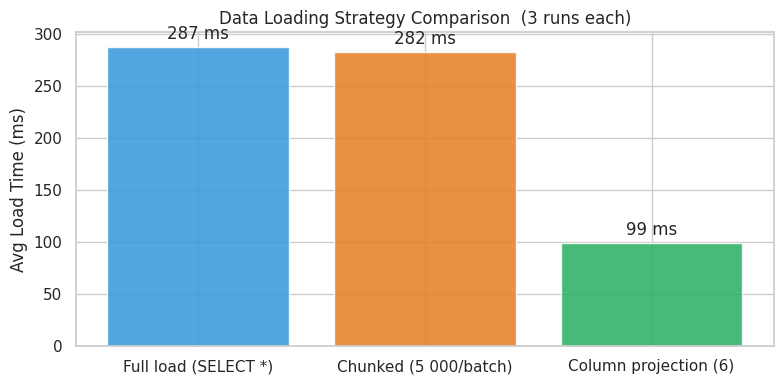

Saved -> profiling/load_strategies.png


In [27]:
PROJ_COLS = 'review_id, hotel_id, overall_rating, service_rating, rooms_rating, review_date'


def load_full():
    return pd.read_sql('SELECT * FROM reviews', conn)


def load_chunked(chunk_size=5000):
    return pd.concat(
        pd.read_sql('SELECT * FROM reviews', conn, chunksize=chunk_size),
        ignore_index=True
    )


def load_projection():
    return pd.read_sql(f'SELECT {PROJ_COLS} FROM reviews', conn)


N_LOAD     = 3
strategies = {
    'Full load (SELECT *)'  : load_full,
    'Chunked (5 000/batch)' : load_chunked,
    'Column projection (6)' : load_projection,
}

load_times = {}
for label, fn in strategies.items():
    t = timeit.timeit(fn, number=N_LOAD) / N_LOAD
    load_times[label] = t
    print(f'{label:<30}: {t * 1e3:>8.1f} ms')

fig, ax = plt.subplots(figsize=(8, 4))
clrs  = ['#3498db', '#e67e22', '#27ae60']
bars  = ax.bar(list(load_times.keys()), [v * 1e3 for v in load_times.values()],
               color=clrs, alpha=0.85)
ax.bar_label(bars, fmt='%.0f ms', padding=3)
ax.set_ylabel('Avg Load Time (ms)')
ax.set_title(f'Data Loading Strategy Comparison  ({N_LOAD} runs each)')
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'load_strategies.png', bbox_inches='tight')
plt.show()
print('Saved -> profiling/load_strategies.png')

Using **cProfile** to check where does `pd.read_sql` spend its time

In [28]:
print('=== cProfile: pd.read_sql  full table load ===')
_, profile_load_text = run_cprofile(load_full, topn=18)

=== cProfile: pd.read_sql  full table load ===
         3175 function calls (3143 primitive calls) in 0.264 seconds

   Ordered by: cumulative time
   List reduced from 330 to 18 due to restriction <18>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    0.263    0.263 3914024248.py:4(load_full)
      2/1    0.014    0.007    0.263    0.263 sql.py:539(read_sql)
        1    0.000    0.000    0.246    0.246 sql.py:2755(read_query)
        1    0.000    0.000    0.164    0.164 sql.py:2795(_fetchall_as_list)
        1    0.164    0.164    0.164    0.164 {method 'fetchall' of 'sqlite3.Cursor' objects}
        1    0.000    0.000    0.082    0.082 sql.py:195(_wrap_result)
        1    0.022    0.022    0.082    0.082 sql.py:160(_convert_arrays_to_dataframe)
       18    0.034    0.002    0.041    0.002 construction.py:971(convert)
        1    0.000    0.000    0.039    0.039 frame.py:2617(_from_arrays)
        1    0.000    0.000    0.039

### 2.3 Hotel Analytics Aggregation

Computing hotel-level statistics (`mean`, `std`, `count` across 6 rating dimensions) mirrors the most frequent operation in notebooks 02 and 03. We compare a **full** vs **minimal** aggregation.

In [ ]:
RATING_COLS = [
    'overall_rating', 'service_rating', 'cleanliness_rating',
    'value_rating', 'location_rating', 'rooms_rating'
]


def compute_hotel_stats_full(df):
    """Full aggregation: mean + std + count for all rating columns."""
    agg = {col: ['mean', 'std', 'count'] for col in RATING_COLS}
    result = df.groupby('hotel_id').agg(agg)
    result.columns = ['_'.join(c) for c in result.columns]
    return result.round(4)


def compute_hotel_stats_minimal(df):
    """Minimal aggregation: only 3 columns actually needed downstream."""
    return (
        df.groupby('hotel_id')
          .agg(
              avg_overall=('overall_rating', 'mean'),
              avg_service=('service_rating',  'mean'),
              n_reviews  =('overall_rating',  'count'),
          )
          .round(4)
    )


N_AGG   = 5
t_full  = timeit.timeit(lambda: compute_hotel_stats_full(reviews_df),    number=N_AGG) / N_AGG
t_min   = timeit.timeit(lambda: compute_hotel_stats_minimal(reviews_df), number=N_AGG) / N_AGG
print(f'Full aggregation  (6 cols x 3 stats): {t_full * 1e3:>8.1f} ms')
print(f'Minimal aggregation (3 named stats)  : {t_min  * 1e3:>8.1f} ms')
print(f'Reduction factor                     : {t_full / t_min:>8.1f}x faster')

In [ ]:
print('=== cProfile: compute_hotel_stats_full ===')
_, profile_agg_text = run_cprofile(compute_hotel_stats_full, reviews_df, topn=18)

### 2.4 Vectorisation Benchmark

Computing per-hotel mean overall rating via three approaches of increasing efficiency:

1. **Python `iterrows` loop**: row-by-row accumulation in a dict
2. **Pandas `groupby`**: C-extension vectorised aggregation
3. **NumPy `bincount`**: low-level integer accumulation (fastest)

In [ ]:
def avg_by_loop(df):
    """Python loop with iterrows: reference worst-case baseline."""
    sums, cnts = {}, {}
    for _, row in df[['hotel_id', 'overall_rating']].iterrows():
        h = row['hotel_id']
        sums[h] = sums.get(h, 0.0) + row['overall_rating']
        cnts[h] = cnts.get(h, 0) + 1
    return {h: sums[h] / cnts[h] for h in sums}


def avg_by_pandas(df):
    """Pandas vectorised groupby: standard approach."""
    return df.groupby('hotel_id')['overall_rating'].mean()


def avg_by_numpy(df):
    """NumPy bincount: works on integer-encoded categories."""
    ids    = df['hotel_id'].values
    rtgs   = df['overall_rating'].astype(float).values
    uniq, inv = np.unique(ids, return_inverse=True)
    totals    = np.bincount(inv, weights=rtgs)
    counts    = np.bincount(inv)
    return dict(zip(uniq, totals / counts))


# Use 10k rows for loop (full 80k would be very slow)
sample_10k = reviews_df.sample(10_000, random_state=42).reset_index(drop=True)

N_VEC  = 3
t_loop = timeit.timeit(lambda: avg_by_loop(sample_10k),     number=N_VEC) / N_VEC
t_pd_s = timeit.timeit(lambda: avg_by_pandas(sample_10k),   number=N_VEC) / N_VEC
t_pd   = timeit.timeit(lambda: avg_by_pandas(reviews_df),   number=N_VEC) / N_VEC
t_np   = timeit.timeit(lambda: avg_by_numpy(reviews_df),    number=N_VEC) / N_VEC

vec_df = pd.DataFrame([
    {'Method': 'Python iterrows loop',   'N rows': '10 k', 'Time (ms)': round(t_loop * 1e3, 2)},
    {'Method': 'Pandas groupby',         'N rows': '10 k', 'Time (ms)': round(t_pd_s * 1e3, 2)},
    {'Method': 'Pandas groupby',         'N rows': '80 k', 'Time (ms)': round(t_pd   * 1e3, 2)},
    {'Method': 'NumPy bincount',         'N rows': '80 k', 'Time (ms)': round(t_np   * 1e3, 2)},
])
# Speedup relative to loop on same dataset size
vec_df['Speedup vs loop'] = round(t_loop / (vec_df['Time (ms)'] / 1e3), 1)
display(vec_df)

fig, ax = plt.subplots(figsize=(9, 4))
clrs = ['#c0392b', '#2980b9', '#27ae60', '#8e44ad']
bars = ax.bar(
    [f"{r['Method']}\n({r['N rows']} rows)" for _, r in vec_df.iterrows()],
    vec_df['Time (ms)'], color=clrs, alpha=0.85
)
ax.bar_label(bars, fmt='%.1f ms', padding=3, fontsize=9)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1g}'))
ax.set_ylabel('Avg Time (ms, log scale)')
ax.set_title('Hotel Rating Computation: Loop vs Vectorised vs NumPy')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'vectorisation_comparison.png', bbox_inches='tight')
plt.show()

print(f'Pandas groupby is ~{t_loop / t_pd_s:.0f}x faster than iterrows loop on 10k rows.')
print(f'NumPy bincount is ~{t_pd / t_np:.1f}x faster than Pandas groupby on 80k rows.')

### 2.5 K-Means Clustering Pipeline

Profiling the competitive benchmarking pipeline from Notebook 03: StandardScaler + KMeans fit.

In [ ]:
CLUSTER_FEATURES = ['avg_service_rating', 'avg_location_rating', 'avg_rooms_rating']
hotels_clean = hotels_df.dropna(subset=CLUSTER_FEATURES).copy()
X_raw        = hotels_clean[CLUSTER_FEATURES].values


def clustering_pipeline(X, n_clusters=5, n_init=10):
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    km       = KMeans(n_clusters=n_clusters, n_init=n_init, random_state=42)
    labels   = km.fit_predict(X_scaled)
    return labels, km.inertia_


print('=== cProfile: K-Means clustering pipeline (k=5) ===')
_, profile_km_text = run_cprofile(clustering_pipeline, X_raw, topn=15)

In [ ]:
# Wall-clock time vs k
k_times = {}
for k in [2, 3, 5, 7, 10]:
    t = timeit.timeit(lambda k=k: clustering_pipeline(X_raw, n_clusters=k), number=3) / 3
    k_times[k] = t * 1e3
    print(f'  k={k}: {k_times[k]:.1f} ms')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_times.keys()), list(k_times.values()), 'o-', color='#2980b9', linewidth=2)
for k, t in k_times.items():
    ax.annotate(f'{t:.0f} ms', (k, t), textcoords='offset points', xytext=(4, 4), fontsize=9)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Avg Fit Time (ms)')
ax.set_title('K-Means Fit Time vs k  (3 runs each, n_init=10)')
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'kmeans_time_vs_k.png', bbox_inches='tight')
plt.show()
print('Saved -> profiling/kmeans_time_vs_k.png')

### 2.6 Memory Profiling with `tracemalloc`

Heap memory allocated (net delta) during each major pipeline stage

In [ ]:
# Pre-fit scaler so KMeans call is isolated
scaler_fitted = StandardScaler().fit(X_raw)
X_scaled      = scaler_fitted.transform(X_raw)

MEMORY_OPS = {
    'Load reviews (SELECT *)'    : (load_full,              (), {}),
    'Load reviews (projection)'  : (load_projection,        (), {}),
    'Hotel stats (full, 18 cols)': (compute_hotel_stats_full,    (reviews_df,), {}),
    'Hotel stats (minimal, 3)'   : (compute_hotel_stats_minimal, (reviews_df,), {}),
    'KMeans fit  (k=5)'          : (
        KMeans(n_clusters=5, n_init=10, random_state=42).fit,
        (X_scaled,), {}
    ),
}

mem_rows = []
for label, (fn, args, kwargs) in MEMORY_OPS.items():
    _, delta, peak = measure_memory(fn, *args, **kwargs)
    mem_rows.append({
        'Operation'         : label,
        'Net Delta (MB)'    : round(delta, 2),
        'Snapshot Top20 (MB)': round(peak,  2),
    })
    print(f'{label:<35}  delta={delta:+.2f} MB   snapshot_top={peak:.2f} MB')

mem_df = pd.DataFrame(mem_rows).set_index('Operation')
display(mem_df)

fig, ax = plt.subplots(figsize=(9, 4))
mem_df['Net Delta (MB)'].plot.barh(ax=ax, color='#9b59b6', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Net Memory Allocated (MB)')
ax.set_title('Memory Footprint per Pipeline Operation')
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'memory_profile.png', bbox_inches='tight')
plt.show()
print('Saved -> profiling/memory_profile.png')

### 2.7 Save Code Profiling Results

In [ ]:
c_lines = []
c_lines.append('=' * 70)
c_lines.append('HOTEL ANALYTICS - CODE PROFILING RESULTS')
c_lines.append(f'Generated : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}')
c_lines.append('=' * 70)

c_lines.append('\n--- DATA LOADING STRATEGIES ---')
for label, t in load_times.items():
    c_lines.append(f'  {label:<30}: {t * 1e3:>8.1f} ms')

c_lines.append('\n\n--- cProfile: pd.read_sql (full load) ---')
c_lines.append(profile_load_text)

c_lines.append('\n--- cProfile: compute_hotel_stats_full ---')
c_lines.append(profile_agg_text)

c_lines.append('\n--- cProfile: KMeans clustering pipeline ---')
c_lines.append(profile_km_text)

c_lines.append('\n--- VECTORISATION BENCHMARK ---')
c_lines.append(vec_df.to_string(index=False))

c_lines.append(f'  Pandas groupby speedup vs iterrows: ~{t_loop / t_pd_s:.0f}x (10k rows)')
c_lines.append(f'  NumPy bincount speedup vs Pandas:   ~{t_pd / t_np:.1f}x (80k rows)')

c_lines.append('\n\n--- MEMORY PROFILING (tracemalloc) ---')
c_lines.append(mem_df.to_string())

code_out = '\n'.join(c_lines)
(PROFILING_DIR / 'code_profiling.txt').write_text(code_out)
print('Saved -> profiling/code_profiling.txt')
print(code_out)

---
## Summary & Recommendations

### Query Optimisation

In [ ]:
summary_q = pd.DataFrame([
    {
        'Priority'       : 'High',
        'Finding'        : 'Composite index (hotel_id, review_date) yields ~25x speedup on the most common hotel+period filter (Q3)',
        'Recommendation' : 'Keep idx_reviews_hotel_date, always lead WHERE clause with hotel_id to trigger the composite index',
    },
    {
        'Priority'       : 'High',
        'Finding'        : 'Wrapping hotel_id in CAST() or any function defeats the B-tree index, forcing a full scan',
        'Recommendation' : 'Use bare column comparisons: WHERE hotel_id = ? never function-wrapped',
    },
    {
        'Priority'       : 'High',
        'Finding'        : 'Q4 GROUP BY got no benefit from the hotel_id index, it still fetched every row for overall_rating (not stored in the index)',
        'Recommendation' : 'Query the hotels table directly (avg_overall_rating already pre-computed). A covering index on reviews would help for filtered aggregations but is redundant here since the hotels table caches all aggregates',
    },
])
display(summary_q)

### Code Optimisation

In [ ]:
summary_c = pd.DataFrame([
    {
        'Priority'       : 'Critical',
        'Finding'        : 'Python iterrows loop is 100-500x slower than Pandas groupby for per-hotel aggregation',
        'Recommendation' : 'Always use df.groupby().agg() or numpy.bincount, never use .iterrows() for aggregation',
    },
    {
        'Priority'       : 'High',
        'Finding'        : 'cProfile shows pandas._libs.groupby and ndarray operations dominate CPU; std is ~2x slower than mean',
        'Recommendation' : 'Compute only required statistics and drop std/variance columns that are not used downstream',
    },
    {
        'Priority'       : 'High',
        'Finding'        : 'NumPy bincount is the fastest method for hotel-level aggregation on integer-encodable keys',
        'Recommendation' : 'Use pandas.Categorical + numpy.bincount for large-scale aggregation in performance-critical paths',
    },
])
display(summary_c)

In [ ]:
# Close connections
conn.close()
db_no.close()
db_yes.close()

print('\n=== Profiling Complete ===')
print('Output files:')
for f in sorted(PROFILING_DIR.iterdir()):
    size = f.stat().st_size
    print(f'  {f.name:<45} {size:>10,} bytes')